In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

## Counts per category of participation level

In [12]:
file_path = "../data/ca_patterns.txt"
df = pd.read_csv(file_path, sep="]: ", engine="python", names=["Pattern", "Count"], header=None)
df["Pattern"] = df["Pattern"].str.replace(r"^\[|\]$", "", regex=True)
df["Count"] = df["Count"].astype(int)
df.head(20)

,Pattern,Count
0,0.0,7037
1,2.0,1731
2,3.0,1674
3,"0.0, 0.0",955
4,1.0,837
5,"0.0, 0.0, 0.0",271
6,"0.0, 3.0",145
7,"2.0, 0.0",140
8,"3.0, 0.0",138
9,"3.0, 3.0",130


## Lift matrix

In [ ]:
file_path = "../data/ca_patterns.txt"
df = pd.read_csv(file_path, sep="]: ", engine="python", names=["Pattern", "Count"], header=None)
df["Pattern"] = df["Pattern"].str.replace(r"^\[|\]$", "", regex=True)
df["Count"] = df["Count"].astype(int)
df.head(20)

In [ ]:
# Step 0: Define states and labels
labels = ["Problem-solution", "Call-to-action", "Intention", "Execution"]
states = ["0.0", "1.0", "2.0", "3.0"]

# Step 1: Extract transitions
def extract_transitions(pattern, count):
    states = pattern.split(", ")
    transitions = [(states[i], states[i+1]) for i in range(len(states)-1)]
    return [(A, B, count) for A, B in transitions]

all_transitions = []
for _, row in df.iterrows():
    all_transitions.extend(extract_transitions(row["Pattern"], row["Count"]))
all_transitions

# Step 2: Aggregate transition counts
transition_counts = Counter()
state_counts = Counter()
B_counts = Counter()
total_transitions = 0

for A, B, count in all_transitions:
    transition_counts[(A, B)] += count
    state_counts[A] += count
    B_counts[B] += count
    total_transitions += count
#transition_counts

# Step 3: Compute probabilities
P_B_given_A = {key: count / state_counts[key[0]] for key, count in transition_counts.items()}
P_B = {B: count / total_transitions for B, count in B_counts.items()}
#P_B_given_A
#P_B

# Step 4: Compute lift
lift = {key: P_B_given_A[key] / P_B[key[1]] for key in transition_counts}
lift_df = pd.DataFrame([
    {"A": A, "B": B, "P_B_given_A": P_B_given_A[(A, B)], "P_B": P_B[B], "Lift": lift[(A, B)]}
    for A, B in lift
])
lift_df.sort_values(by="Lift", ascending=False)

# Step 5: Create transition matrix for heatmap
states = ["0.0", "1.0", "2.0", "3.0"]
matrix = np.zeros((4, 4))
for (A, B), value in lift.items():
    i, j = states.index(A), states.index(B)
    matrix[i, j] = value

plt.figure(figsize=(8, 6))
ax = sns.heatmap(matrix, annot=True, xticklabels=labels, yticklabels=labels, cmap="crest", fmt=".2f")
plt.ylabel("From")
plt.xlabel("To", labelpad=15)  # Move the x-axis label up
plt.gca().xaxis.set_label_position("top")  # Position x-axis label at the top
plt.gca().tick_params(axis='x', top=True, labeltop=True, labelbottom=False)  # Show labels at the top

# Add label to colorbar
colorbar = ax.collections[0].colorbar
colorbar.set_label("Lift")

#plt.savefig("../plots/transition_matrix.pdf")

plt.show()

In [ ]:
# Calculate upper triangle sum (excluding diagonal)
upper_triangle_sum = np.sum(np.triu(matrix, k=1))

# Calculate lower triangle sum (excluding diagonal)
lower_triangle_sum = np.sum(np.tril(matrix, k=-1))

print("Upper Triangle Sum:", upper_triangle_sum)
print("Lower Triangle Sum:", lower_triangle_sum)

### v2 (aggregating identical consecutive symbols into one)

AEEEEEAAE to AEAE

In [2]:
file_path = "../data/ca_patterns.txt"
df = pd.read_csv(file_path, sep="]: ", engine="python", names=["Pattern", "Count"], header=None)
df["Pattern"] = df["Pattern"].str.replace(r"^\[|\]$", "", regex=True)
df["Count"] = df["Count"].astype(int)
df

,Pattern,Count
0,0.0,7037
1,2.0,1731
2,3.0,1674
3,"0.0, 0.0",955
4,1.0,837
...,...,...
522,"1.0, 2.0, 0.0, 0.0, 1.0, 0.0",1
523,"1.0, 3.0, 1.0, 1.0, 3.0, 0.0",1
524,"1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0",1
525,"1.0, 1.0, 2.0, 2.0, 3.0, 1.0, 1.0",1


In [3]:
df = df.astype({"Pattern":"str"})
df["Pattern"] = df["Pattern"].apply(lambda x: x.split(", "))
df["Pattern"].head(10)

0              [0.0]
1              [2.0]
2              [3.0]
3         [0.0, 0.0]
4              [1.0]
5    [0.0, 0.0, 0.0]
6         [0.0, 3.0]
7         [2.0, 0.0]
8         [3.0, 0.0]
9         [3.0, 3.0]
Name: Pattern, dtype: object

In [4]:
def aggregate_consecutive(pattern):
    aggregated = [pattern[0]]
    for i in range(1, len(pattern)):
        if pattern[i] != pattern[i-1]:
            aggregated.append(pattern[i])
    return aggregated

df['Pattern'] = df['Pattern'].apply(aggregate_consecutive)
df.head(10)

,Pattern,Count
0,[0.0],7037
1,[2.0],1731
2,[3.0],1674
3,[0.0],955
4,[1.0],837
5,[0.0],271
6,"[0.0, 3.0]",145
7,"[2.0, 0.0]",140
8,"[3.0, 0.0]",138
9,[3.0],130


In [ ]:
# # for all values in the list in the pattern column, convert them to int
# df["Pattern"] = df["Pattern"].apply(lambda x: [int(float(i)) for i in x])
# df.head(10)

In [ ]:
# Step 0: Define states and labels
labels = ["Problem-solution", "Call-to-action", "Intention", "Execution"]
states = ["0.0", "1.0", "2.0", "3.0"]

# Step 1: Extract transitions
def extract_transitions(pattern, count):
    # Ensure pattern is a list before processing
    if not isinstance(pattern, list):
        pattern = eval(pattern)  # Convert string representation of a list into an actual list (if needed)
    
    transitions = [(str(pattern[i]), str(pattern[i+1])) for i in range(len(pattern)-1)]
    return [(A, B, count) for A, B in transitions]

all_transitions = []
for _, row in df.iterrows():
    all_transitions.extend(extract_transitions(row["Pattern"], row["Count"]))
all_transitions

# Step 2: Aggregate transition counts
transition_counts = Counter()
state_counts = Counter()
B_counts = Counter()
total_transitions = 0

for A, B, count in all_transitions:
    transition_counts[(A, B)] += count
    state_counts[A] += count
    B_counts[B] += count
    total_transitions += count
transition_counts

# Step 3: Compute probabilities
P_B_given_A = {key: count / state_counts[key[0]] for key, count in transition_counts.items()}
P_B = {B: count / total_transitions for B, count in B_counts.items()}
#P_B_given_A
#P_B

# Step 4: Compute lift
lift = {key: P_B_given_A[key] / P_B[key[1]] for key in transition_counts}
lift_df = pd.DataFrame([
    {"A": A, "B": B, "P_B_given_A": P_B_given_A[(A, B)], "P_B": P_B[B], "Lift": lift[(A, B)]}
    for A, B in lift
])
lift_df.sort_values(by="Lift", ascending=False)

,A,B,P_B_given_A,P_B,Lift
5,1.0,0.0,0.640385,0.371411,1.724193
1,2.0,0.0,0.628613,0.371411,1.692498
2,3.0,0.0,0.609524,0.371411,1.641103
0,0.0,3.0,0.369254,0.230910,1.599124
4,0.0,1.0,0.318011,0.199756,1.591998
3,0.0,2.0,0.312735,0.197923,1.580086
6,2.0,3.0,0.238439,0.230910,1.032606
7,3.0,2.0,0.200000,0.197923,1.010494
8,3.0,1.0,0.190476,0.199756,0.953546
9,1.0,3.0,0.194231,0.230910,0.841153


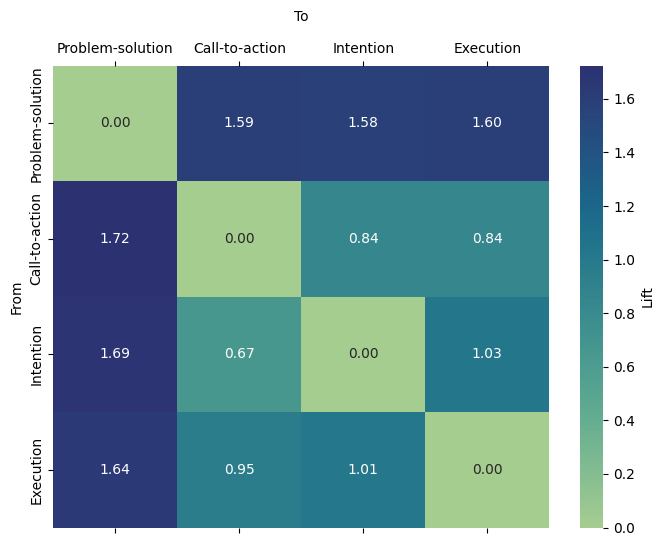

In [10]:
# Step 5: Create transition matrix for heatmap
states = ["0.0", "1.0", "2.0", "3.0"]
matrix = np.zeros((4, 4))
for (A, B), value in lift.items():
    i, j = states.index(A), states.index(B)
    matrix[i, j] = value

plt.figure(figsize=(8, 6))
ax = sns.heatmap(matrix, annot=True, xticklabels=labels, yticklabels=labels, cmap="crest", fmt=".2f")
plt.ylabel("From")
plt.xlabel("To", labelpad=15)  # Move the x-axis label up
plt.gca().xaxis.set_label_position("top")  # Position x-axis label at the top
plt.gca().tick_params(axis='x', top=True, labeltop=True, labelbottom=False)  # Show labels at the top

# Add label to colorbar
colorbar = ax.collections[0].colorbar
colorbar.set_label("Lift")

#plt.savefig("../plots/transition_matrix.pdf")

plt.show()

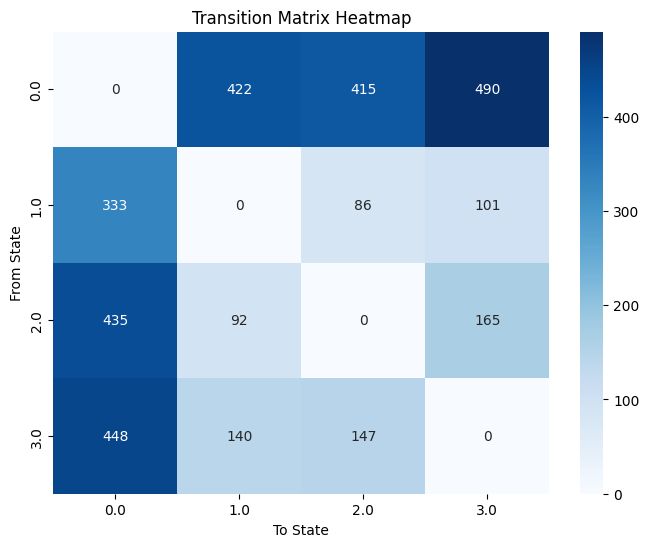

In [ ]:
# # Extract unique states
# states = sorted(set(i for i, j in transition_counts.keys()).union(j for i, j in transition_counts.keys()))
# state_to_idx = {state: idx for idx, state in enumerate(states)}

# # Create transition matrix
# matrix = np.zeros((len(states), len(states)))
# for (from_state, to_state), count in transition_counts.items():
#     matrix[state_to_idx[from_state], state_to_idx[to_state]] = count

# # Plot heatmap
# plt.figure(figsize=(8, 6))
# sns.heatmap(matrix, annot=True, fmt=".0f", cmap="Blues", xticklabels=states, yticklabels=states)
# plt.xlabel("To State")
# plt.ylabel("From State")
# plt.title("Transition Matrix Heatmap")
# plt.show()

In [11]:
# Calculate upper triangle sum (excluding diagonal)
upper_triangle_sum = np.sum(np.triu(matrix, k=1))

# Calculate lower triangle sum (excluding diagonal)
lower_triangle_sum = np.sum(np.tril(matrix, k=-1))

print("Upper Triangle Sum:", upper_triangle_sum)
print("Lower Triangle Sum:", lower_triangle_sum)

Upper Triangle Sum: 7.480567509049681
Lower Triangle Sum: 7.687387380431565
